In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import random
import math

random.seed(19)
batch_size = 8
learning_rate = 0.01

In [28]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

print("X_train data shape:", X_train.shape)
print("Y_train data shape:", y_train.shape)
print("X_test data shape:", X_test.shape)
print("y_test data shape:", y_test.shape)


X_train data shape: (60000, 28, 28)
Y_train data shape: (60000,)
X_test data shape: (10000, 28, 28)
y_test data shape: (10000,)


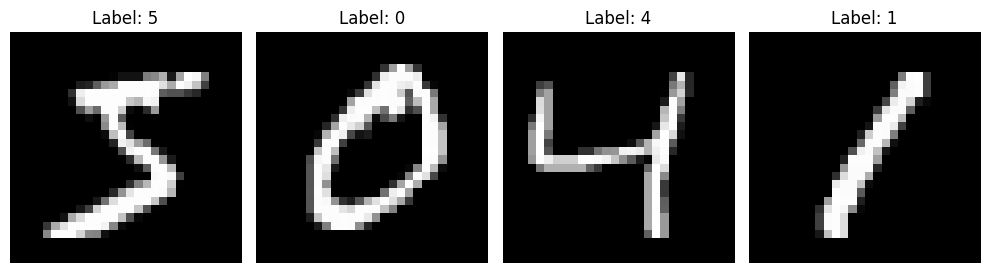

In [29]:
plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
layer1 = [] # list of length 28*28=784 neurons

weights_layer12 = [[random.randint(-99,99)/100 for _ in range(X_train.shape[1]*X_train.shape[2])] for _ in range(16)]
biases_layer2 = [random.randint(-99,99)/100 for _ in range (16)]

layer2 = [0 for _ in range(0,16)] #list of length 16 neurons

weights_layer23 = [[random.randint(-99,99)/100 for _ in range(16)] for _ in range(10)]
biases_layer3 = [random.randint(-99,99)/100 for _ in range (10)]

layer3=[] #list of length 10 neurons


In [ ]:
for batch in range(0,len(X_train),batch_size):
    labels=[label for label in y_train[batch:batch+batch_size]]
    gradients = []
    for image in range(0,batch_size):
        layer1 = image
        layer2 = []
        for layer2_neuron in range(0,16):
            z_func = sum([a[0]*a[1] for a in zip(weights_layer12[0],[pixel for row in image for pixel in row])]) + biases_layer2[layer2_neuron]
            layer2.append(z_func)
        layer3 = []
        for layer3_neuron in range(0,10):
            z_func = sum([a[0]*max(0,a[1]) for a in zip(weights_layer23[0],layer2)]) + biases_layer3[layer3_neuron]
            layer3.append(z_func)
        logits = [round(math.exp(max(0,logit)),2) for logit in layer3]
        sumexp = sum(layer3)
        probs = [prob/sumexp for prob in layer3]
        loss = -1 * math.log(probs[labels[image]])
        print(loss)
        probs[labels[image]]-=1
        if gradients:
            gradients = [old_avg+(new_grad-old_avg)/image for (old_avg,new_grad) in zip(gradients,probs)]
        else:
            gradients = probs


28
0


In [35]:
print(bool([0]))

True
